# Titanic Survival Prediction
**Author:** Tan Han Rong  
**Course:** Specialist Diploma in Data Science (AI), Singapore Polytechnic  
**Dataset:** [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic)

## Objective
Predict passenger survival on the Titanic using classification models, 
including Random Forest, K-Nearest Neighbours (KNN), and Logistic Regression.

## Approach
1. Exploratory Data Analysis (EDA) and visualisation of missing data
2. Feature engineering (title extraction for age imputation)
3. Data preprocessing (encoding, scaling, feature selection)
4. Model training and comparison
5. Cross-validation and evaluation
6. Prediction on test set for Kaggle submission

# Insert Functions + Start with Random Forest Classifier 

In [1]:
#Import the functions

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score

#This was added later to include KNN and Logistic Regression models

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
# Load Titanic dataset
df = pd.read_csv('train.csv')

# Display the first few rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Exploratory Data Analysis

We begin by loading the training dataset and visualising missing values 
to understand where imputation is needed.

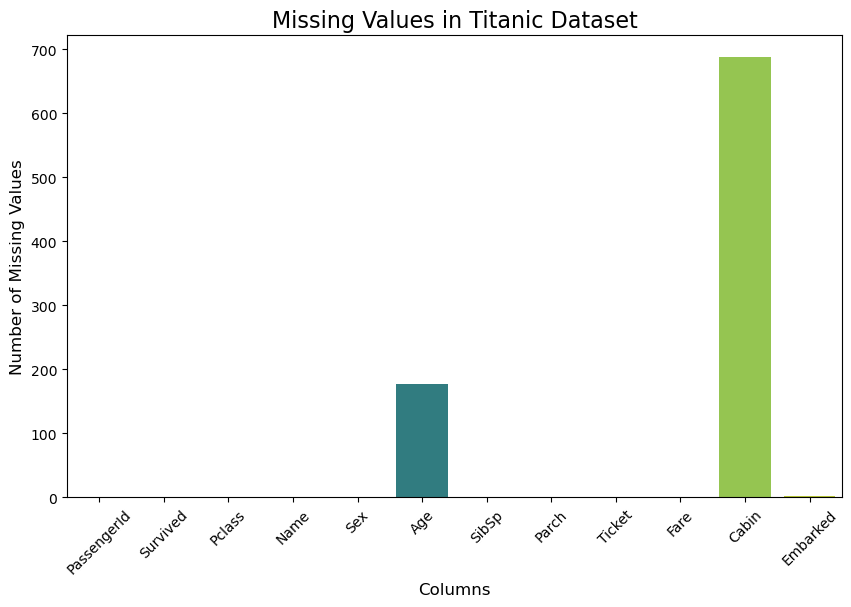

In [3]:
# Check for missing values (with the help of ChatGPT)
missing_values = df.isnull().sum()

# Create a bar plot for missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
plt.title("Missing Values in Titanic Dataset", fontsize=16)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)
plt.xticks(rotation=45)
plt.show()

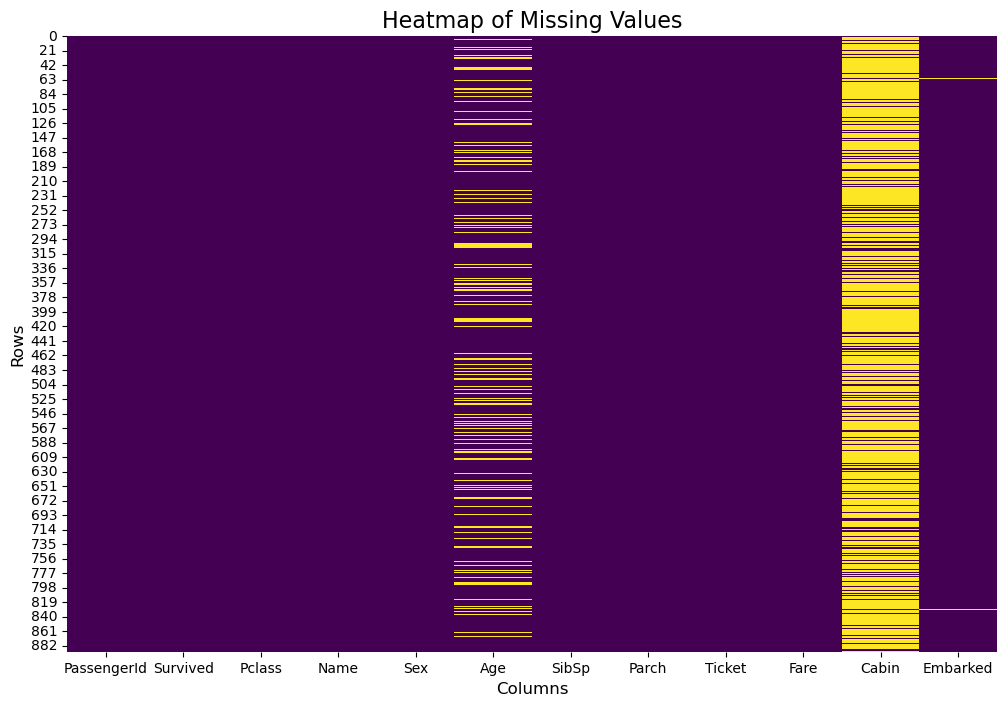

In [4]:
#Displaying a heatmap to show missing values

plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values", fontsize=16)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows", fontsize=12)
plt.show()

# Attempt to use salutations, group them up and fill up missing values with the median ages of said groups

## 2. Feature Engineering — Title-Based Age Imputation

Rather than simply filling missing `Age` values with the overall median, 
we extract titles (e.g. Mr, Mrs, Miss, Master) from passenger names 
to impute age more accurately using group-specific medians.

This approach preserves meaningful age variation across social groups 
and reduces imputation bias.

In [5]:
# Extraction of Titles
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.') #str.extract helps to remove pesky commas, periods and other stuff.

# Display unique titles
print("Unique titles extracted:")
print(df['Title'].unique())

Unique titles extracted:
['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']


In [6]:
# Replace rare titles with common ones (ChatGPT said this is optional)
title_replacements = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Lady': 'Mrs', 'Countess': 'Mrs',
    'Sir': 'Mr', 'Don': 'Mr', 'Dr': 'Mr', 'Rev': 'Mr', 'Major': 'Mr',
    'Col': 'Mr', 'Capt': 'Mr', 'Jonkheer': 'Mr'
}
df['Title'] = df['Title'].replace(title_replacements)

In [7]:
# Group by 'Title' and compute the median age
median_age_by_title = df.groupby('Title')['Age'].median()

# Display median ages for each title
print("Median ages by title:")
print(median_age_by_title)

Median ages by title:
Title
Master           3.5
Miss            21.0
Mr              30.0
Mrs             35.0
the Countess    33.0
Name: Age, dtype: float64


In [8]:
# Fill missing age values with the median age for their title
def fill_age(row):
    if pd.isnull(row['Age']):
        return median_age_by_title[row['Title']]
    return row['Age']

df['Age'] = df.apply(fill_age, axis=1)

# Verify no missing values remain in the 'Age' column
print("\nMissing values in 'Age':", df['Age'].isnull().sum())


Missing values in 'Age': 0


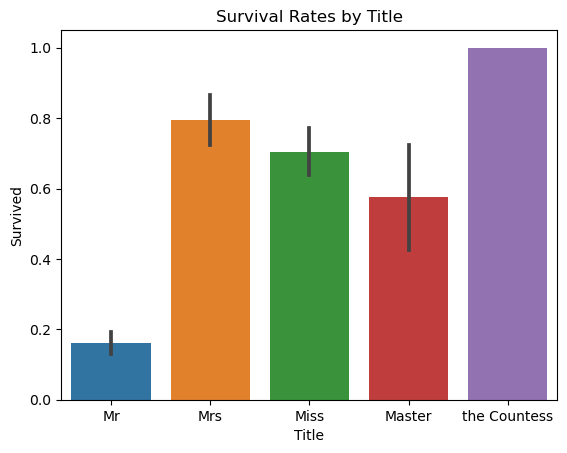

In [9]:
# Survival rates by Title
sns.barplot(data=df, x='Title', y='Survived')
plt.title('Survival Rates by Title')
plt.show()

# Embarked Test

In [10]:
# Checking Embarked

# Display unique Embarkation location
print("Unique Embarkation locations extracted:")
print(df['Embarked'].unique())

Unique Embarkation locations extracted:
['S' 'C' 'Q' nan]


# Additional workings

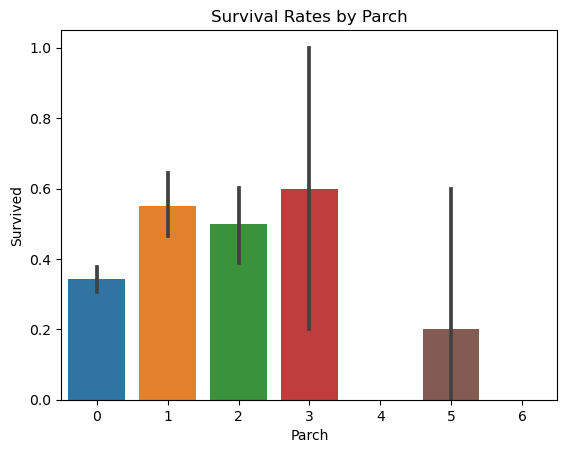

In [11]:
# Parch survival impact
sns.barplot(data=df, x='Parch', y='Survived')
plt.title('Survival Rates by Parch')
plt.show()

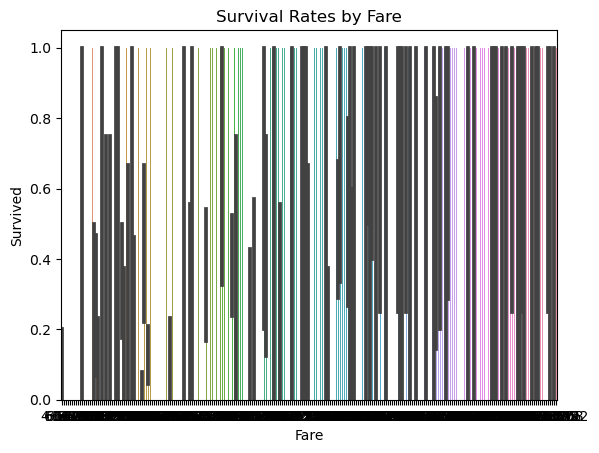

In [12]:
# Fare survival impact
sns.barplot(data=df, x='Fare', y='Survived')
plt.title('Survival Rates by Fare')
plt.show()

# Additional cleaning of the data

## 3. Data Preprocessing

We fill remaining missing values, drop low-signal or high-cardinality columns, 
and encode categorical variables for modelling.

**Dropped columns:** Name, Ticket, Cabin (too many missing values or non-informative), 
Parch, SibSp (family size signals already captured elsewhere), Title (used for imputation only).

In [13]:
# Fill missing 'Embarked' with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop columns that won't be useful for modeling
df.drop(['Name', 'Ticket', 'Cabin', 'Parch', 'SibSp', 'Title'], axis=1, inplace=True) #dropped title cause I added it previously

## 4. Model Training

We train three classifiers:
- **Random Forest** — ensemble of decision trees, robust to overfitting
- **K-Nearest Neighbours (KNN)** — distance-based classifier, requires feature scaling
- **Logistic Regression** — linear classifier, useful for interpretability

We use an 80/20 train-test split with `random_state=42` for reproducibility.

In [14]:
# Encode categorical variables (Sex and Embarked)
le = LabelEncoder()

# Encode 'Sex'
df['Sex'] = le.fit_transform(df['Sex'])

# Encode 'Embarked'
df['Embarked'] = le.fit_transform(df['Embarked'])

In [15]:
# Define features and target variable by separating the target variable from the features
X = df.drop('Survived', axis=1)  # Features
y = df['Survived']  # Target variable

In [16]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Initialize the RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
# Standardize features for KNN (optional for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Initialize models
knn = KNeighborsClassifier(n_neighbors=5)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [20]:
# Train models
knn.fit(X_train_scaled, y_train)
log_reg.fit(X_train, y_train)  # Logistic Regression does not require scaling in most cases

LogisticRegression(max_iter=1000, random_state=42)

In [21]:
# Make predictions
knn_predictions = knn.predict(X_test_scaled)
log_reg_predictions = log_reg.predict(X_test)

In [22]:
# Evaluate models
print("KNN Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, knn_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_predictions))
print("Classification Report:\n", classification_report(y_test, knn_predictions))

print("\nLogistic Regression Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, log_reg_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_reg_predictions))
print("Classification Report:\n", classification_report(y_test, log_reg_predictions))

KNN Model Evaluation:
Accuracy: 0.7932960893854749
Confusion Matrix:
 [[89 16]
 [21 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


Logistic Regression Model Evaluation:
Accuracy: 0.7988826815642458
Confusion Matrix:
 [[88 17]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [23]:
# Logistic Regression Feature Importance
print("\nFeature Importance (Logistic Regression Coefficients):")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_reg.coef_[0]
}).sort_values(by='Importance', key=abs, ascending=False) #making it easier to see based which 
#is most important on top, then move downwards

print(feature_importance)


Feature Importance (Logistic Regression Coefficients):
       Feature  Importance
2          Sex   -2.461652
1       Pclass   -0.986695
5     Embarked   -0.285968
3          Age   -0.023065
0  PassengerId    0.000381
4         Fare    0.000230


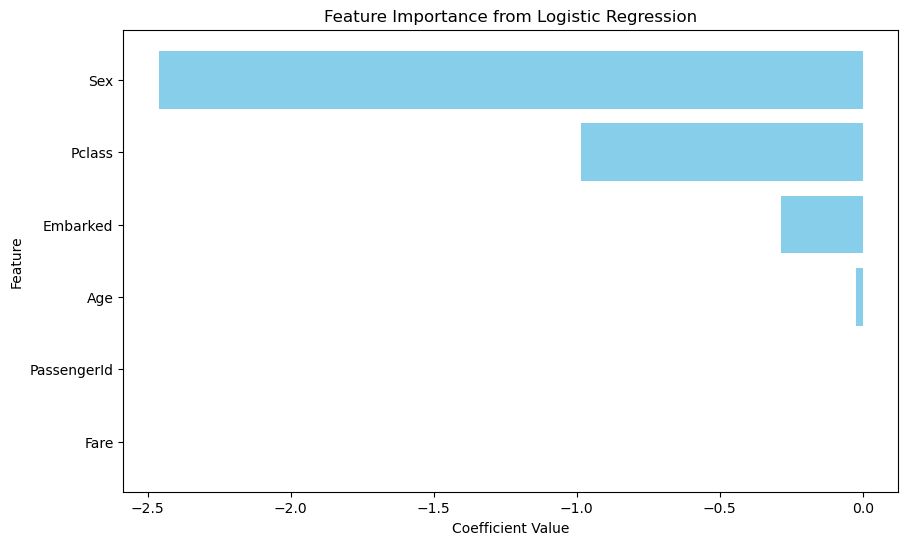

In [24]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance from Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

# Running Random Forest Model

In [25]:
# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.82
Confusion Matrix:
[[93 12]
 [21 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



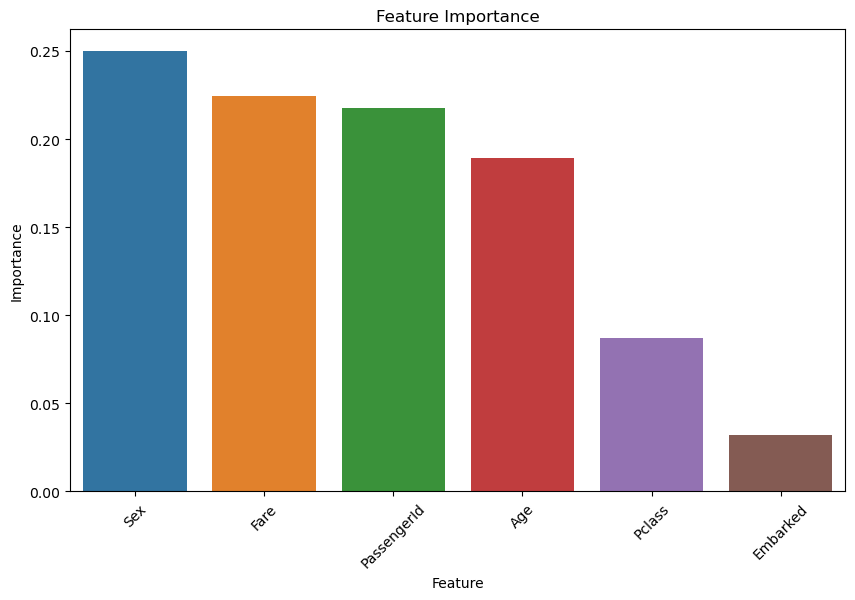

In [26]:
# Get feature importance
feature_importances = rf.feature_importances_

# Create a DataFrame to view feature importances
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Feature', y='Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

## 5. Cross-Validation

To get a more reliable estimate of model performance, 
we run 5-fold cross-validation on the full training set using the Random Forest model.
This reduces variance in our accuracy estimate compared to a single train-test split.

In [27]:
# Perform cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5)  # 5-fold cross-validation
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Cross-Validation Score: {cv_scores.mean():.2f}")

Cross-Validation Scores: [0.70391061 0.79213483 0.83146067 0.79775281 0.83707865]
Mean Cross-Validation Score: 0.79


# Testing the model on Test Data

In [ ]:
## 6. Generating Kaggle Submission

We apply the trained Random Forest model to the held-out Kaggle test set 
and export predictions to `rfdraft_titanic_predictions.csv`.

**Best Kaggle Public Score:** 0.78708 (Random Forest Classifier)

In [28]:
# Load the dataset
df = pd.read_csv('test.csv') 

# Display column names to debug any issues with missing columns
print("Initial columns:", df.columns)

Initial columns: Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [29]:
# Handle missing 'Age' using a SimpleImputer
imputer = SimpleImputer(strategy='median')  # Reuse the same imputer as for training
df['Age'] = imputer.fit_transform(df[['Age']])  # Apply imputer to 'Age'

# Handle missing 'Embarked' by filling with the most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Handle missing 'Fare' by filling with the median value
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Drop columns that are unnecessary for modeling
df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces in column names
df.drop(['Name', 'Ticket', 'Cabin', 'Parch', 'SibSp'], axis=1, inplace=True, errors='ignore')

# Check columns after dropping
print("Columns after dropping:", df.columns)

Columns after dropping: Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')


In [30]:
# Encode categorical variables
le = LabelEncoder()

# Concatenate training and test data for consistent encoding if necessary
# (Assume `train_df` exists if using both datasets)
if 'Sex' in df.columns:
    df['Sex'] = le.fit_transform(df['Sex'])  # Encode 'Sex'

if 'Embarked' in df.columns:
    df['Embarked'] = le.fit_transform(df['Embarked'])  # Encode 'Embarked'

(Post submission notes: Code Quality)

There's one minor issue worth being aware of: in the test set section (cell 30), usage of le.fit_transform() instead of le.transform() for the encoding. This means I am re-fitting the encoder on the test set rather than applying the same encoding learned from training — which could cause label misalignment if the test set has different categories. It didn't affect the score in this case (since Sex and Embarked are consistent), but it's worth noting for future projects.

In [31]:
# Define the features (X) for prediction
X_test = df.drop('Survived', axis=1, errors='ignore')  # Remove 'Survived' column if it exists

# Make predictions
y_pred_test = rf.predict(X_test)

# Save or display the predictions
output = pd.DataFrame({
    'PassengerId': df['PassengerId'],
    'Survived': y_pred_test
})

# Save predictions to a CSV file
output.to_csv('rfdraft_titanic_predictions.csv', index=False)

# Display the first few rows of predictions
print(output.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
